# <center><strong><span style="color: rgb(255, 69, 147);">Simulación del Descubrimiento de Neptuno mediante Optimizaciones de Perturbaciones Orbitales</span><strong><center> 









**Contexto Histórico**


El descubrimiento del planeta Neptuno fue, en su época, uno de los acontecimientos más relevantes para la astronomía, en donde aún se debatía sobre el descubrimiento de planetas no conocidos a partir de otros planetas que sí lo eran, en donde Neptuno fue considerado un "planeta invisible" hasta que en 1846 se le denominó por su nombre actual.

Johann Galle fue un astrónomo de la universidad de Berlín, quién, observando el cielo, notó la presencia de un planeta desconocido gracias a las especificaciones matemáticas de quién es considerado el descubridor de Neptuno, Urbain Leverrier. Sin embargo, otro científico se encontraba investigando sobre la presencia de un planeta vecino a Urano, Jhon Adams, y si bien este último fue el primero en finalizar los cálculos que demostraban teóricamente la presencia de Neptuno, finalmente se le dió el reconocimiento a Urbain Leverrier dado que fue él quien dió las especificaciones para poder encontrar al planeta a través de un telescopio.

**Teoría de Newton y Ley de Gravitación Universal**

Es imposible comprender el descubrimiento de Neptuno sin tener en consideración la estructura y dinámica de la Teoría de la gravitación universal de Sir Isaac Newton.



In [16]:
#----------------------------------------------PASO 1----------------------------------------------
#Simulación Urano-Sol

import numpy as np
import matplotlib.pyplot as plt
from ode_solvers_ import *

# Problema de 2 cuerpos simplificado
def f_gravitational_us(t, r, v):
    G = 6.672e-11 # constante de gravitación universal
    M = 1.9891e30 # masa del sol
    
    r_vector = r

    return -G*M * r_vector / np.linalg.norm(r_vector)**3

# Parámetros del problema
t0 = 0  # s
tf = 365 * 24 * 3600 * 84 * 2 #s #pero son 168 años de simulación
h = 24 * 3600 #s #tamaño de paso de un dia
r0 = np.array([2.871e12, 0]) #metros
v0 = np.array([0, 6830]) #m/s

# Métodos

t, r_urano, v_urano = verlet_method_second_order_2D(
    f=f_gravitational_us, 
    t0=0, 
    r0=r0, 
    v0=v0, 
    tf=tf,
    h=h
)


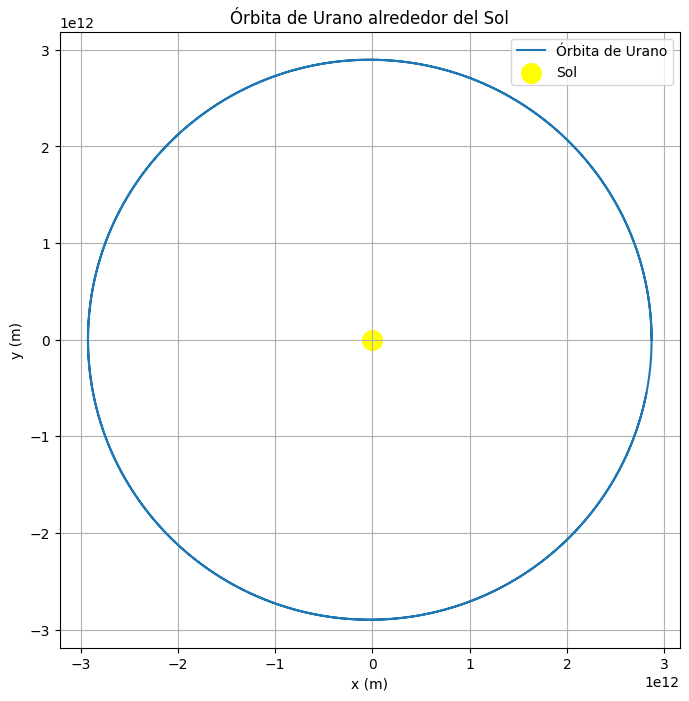

In [19]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 8))
plt.plot(r_urano[:, 0], r_urano[:, 1], label="Órbita de Urano")
plt.scatter(0, 0, color="yellow", label="Sol", s=200)
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Órbita de Urano alrededor del Sol")
plt.legend()
plt.grid()
# plt.axis("equal")
plt.show()

Text(0.5, 1.0, 'Distancia de Urano al Sol a lo largo del tiempo')

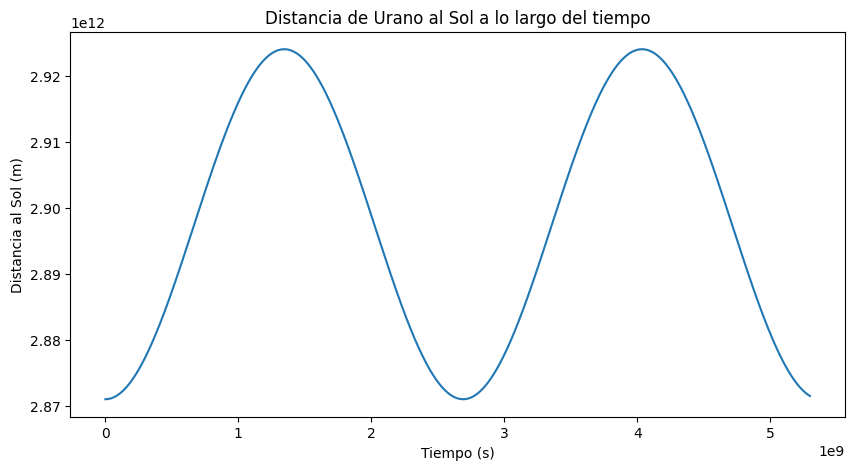

In [21]:
modulo_orbita = np.linalg.norm(r_urano, axis=1)

plt.figure(figsize=(10, 5))
plt.plot(t, modulo_orbita)
plt.xlabel("Tiempo (s)")
plt.ylabel("Distancia al Sol (m)")
plt.title("Distancia de Urano al Sol a lo largo del tiempo")

Start simulation
Step 61362/61362 completed.
Completed simulation!


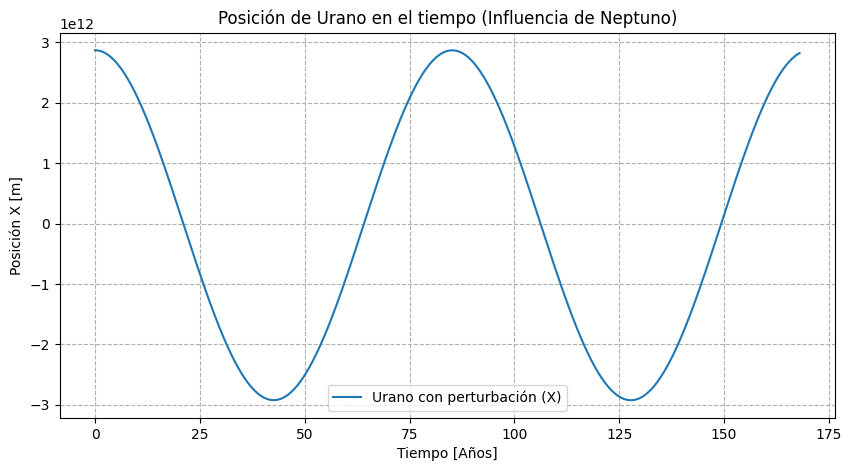

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from nbody_simulation_tools import CelestialBody, NBodySimulation

G = 6.67430e-11 # Usando la constante del archivo de tu profe
M_sol = 1.9891e30 

# 1. Definir los Cuerpos Celestes (Asegúrate de que r0 y v0 existan)
r0 = (2.871e12, 0)
v0 = (0, 6830)

sol = CelestialBody(mass=M_sol, init_position=(0, 0), init_velocity=(0, 0), name="Sol")
urano = CelestialBody(mass=8.6810e25, init_position=r0, init_velocity=v0, name="Urano")

# Parámetros del perturbador (Neptuno) [cite: 26, 27]
phi_p = np.pi/4 
a_p = 4.5e12 
v_p_mag = np.sqrt(G * M_sol / a_p)

# Posición y velocidad vectorial [cite: 23]
pos_p = (a_p * np.cos(phi_p), a_p * np.sin(phi_p))
vel_p = (-v_p_mag * np.sin(phi_p), v_p_mag * np.cos(phi_p))

perturbador = CelestialBody(mass=1.024e26, init_position=pos_p, init_velocity=vel_p, name="Neptuno")

# 2. Configurar y Correr la Simulación
dt = 24 * 3600 # Paso de 1 días
num_steps = int((365.25 * 24 * 3600 * 84 * 2) / dt) # Simulación de 168 años
sim = NBodySimulation(dt=dt, num_steps=num_steps)

sim.add_body(sol)
sim.add_body(urano)
sim.add_body(perturbador)

sim.run_simulation()
pos_urano_ref = perturbador.positions.copy()

# 3. Graficar Posición vs Tiempo
# Creamos el vector de tiempo en años para que sea fácil de leer
tiempo_anios = (np.arange(num_steps) * dt) / (365.25 * 24 * 3600)

plt.figure(figsize=(10, 5))
# Graficamos la componente X de la posición de Urano
plt.plot(tiempo_anios, urano.positions[:, 0], label="Urano con perturbación (X)")

plt.title("Posición de Urano en el tiempo (Influencia de Neptuno)")
plt.xlabel("Tiempo [Años]")
plt.ylabel("Posición X [m]")
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

In [28]:
def funcion_objetivo(params):
    m_p, phi_0 = params  # Masa y fase inicial del planeta perturbador
    
    # Re-inicializar cuerpos para cada iteración
    s = CelestialBody(mass=1.9891e30, x=0, y=0, vx=0, vy=0)
    u = CelestialBody(mass=8.681e25, x=2.871e12, y=0, vx=0, vy=6830)
    
    # Planeta perturbador con órbita circular simplificada
    r_p = 4.495e12
    x_p = r_p * np.cos(phi_0)
    y_p = r_p * np.sin(phi_0)
    v_mag = np.sqrt(6.672e-11 * 1.9891e30 / r_p)
    vx_p = -v_mag * np.sin(phi_0)
    vy_p = v_mag * np.cos(phi_0)
    
    p = CelestialBody(mass=m_p, x=x_p, y=y_p, vx=vx_p, vy=vy_p)
    
    # Simulación rápida
    sim_test = NBodySimulation(dt=24*3600*10, num_steps=len(pos_urano_ref)//10)
    sim_test.add_body(s); sim_test.add_body(u); sim_test.add_body(p)
    sim_test.run_simulation()
    
    # Calcular RMSE (Error Cuadrático Medio)
    # Nota: Asegurarse de comparar los mismos pasos de tiempo
    diff = u.positions - pos_urano_ref[::10]
    error = np.sqrt(np.mean(np.sum(diff**2, axis=1)))
    return error